In [887]:
from collections import defaultdict
import copy
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.dagcircuit import DAGCircuit, DAGOpNode, DAGInNode, DAGOutNode
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.transpiler.layout import Layout
from qiskit.circuit.quantumregister import Qubit
from qiskit.visualization import dag_drawer
from qiskit.qasm import Qasm

import matplotlib.pyplot as plt
import networkx as nx

from vfsexp import Vf

In [888]:
""" From a QuantumCircuit, remove all 1qb gates and any 2qb gate [p,q] that has a parent [p,q] or [q,p]"""
def remove_1q_and_consecutive_2q_gates_in_circuit(circuit):

    newcirc = QuantumCircuit(circuit.num_qubits)
    record = [] #the current end layer of the reduced circuit
    for instruction in circuit:
        if len(instruction.qubits) != 2: continue
        if instruction.operation.name == 'cx': # only consider cx gates
            p, q = instruction.qubits[0]._index, instruction.qubits[1]._index
            if [p,q] in record or [q,p] in record:
                continue
            for x in record:
                if p in x or q in x:
                    record.remove(x)
            record.append([p,q])            
            newcirc.cx(p,q)
    return newcirc

def graph_of_circuit(circuit):
    ''' Return the induced graph of the reduced circuit C
            - node set: qubits in C
            - edge set: all pair (p,q) if CNOT [p,q] or CNOT[q,p] in C
        Args:
            C (list): the input reduced circuit
        Returns:
            g (Graph)
    '''   
    g = nx.Graph()
    for gate in circuit:
        if gate.operation.name != 'cx': continue
        p, q = gate.qubits[0]._index, gate.qubits[1]._index
        g.add_edge(p,q)
    return g  

def has_cycle_3(graph):
    for u in graph.nodes():
        for v in graph.neighbors(u):
            for w in graph.neighbors(v):
                if u != w and graph.has_edge(u, w):
                    return True
    return False

def fast_no_embedding(subgraph, graph):
    # for AG with no 3-cycle
    if has_cycle_3(subgraph) and not has_cycle_3(graph): 
        return True
    
    subgraph_deg = list(nx.degree(subgraph, v) for v in subgraph.nodes())
    subgraph_deg.sort(reverse=True)
    
    graph_deg = list(nx.degree(subgraph, v) for v in subgraph.nodes())
    graph_deg.sort(reverse=True)
    
    l = len(subgraph_deg)
    for idx in range(l):
        if subgraph_deg[idx] > graph_deg[idx]:
            return True
        
    return False

def is_embeddable(g, H, stop):
    '''check if a small graph g is embeddable in a large H, anchor is bool
        g, H (Graph)
        stop (float): time limit for vf2
    '''
    if fast_no_embedding(g, H):
        return False, {}
    
    lng = len(nx.nodes(g))
        
    new_g = g.copy()
    #print(len(new_g.edges()) == len(g.edges()))

    new_H = H.copy()
    temp_map = dict()

    vf2 = Vf(new_g, new_H, {}, stop)
    result = vf2.dfsMatch({})
    if len(result) == lng:
        return True, temp_map.update(result)  
    return False, {}

def draw_nx_graph(g):
    if isinstance(g, DAGCircuit): 
        qc = dag_to_circuit(g)
        g = graph_of_circuit(qc)
    
    if not isinstance(g, nx.Graph):
        raise Exception('g should be a nx.Graph')
        
    # Create a layout for the nodes
    pos = nx.spring_layout(g) #sl !!not sure if this is the correct layout for us!!

    # Draw the nodes and edges
    nx.draw(g, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=12, font_color='black')

    # Display the graph
    plt.show()

In [889]:
def _successors(node, dag):
    for _, successor, edge_data in dag.edges(node):
        if not isinstance(successor, DAGOpNode):
            continue
        #"""Our dag is derived from special circuit with 1q gates and 2q consecutive identical gates removed."""
        #if isinstance(node, DAGOpNode) and successor.qargs == node.qargs: 
        #    continue #sl sometimes successor and node are identical, don't know why
        if isinstance(edge_data, Qubit):
            yield successor

In [895]:
from ag import qgrid, q20
import time
import os

"""Divide-and-Conquer works fine on Tokyo and phase_estimation, phase_oracle, AND, OR, """
path = '../bench/qiskit_circuit_benchmark/' 
#filename = 'excitation_preserving_10.qasm'
#filename = 'grover_operator_10.qasm'
filename = 'and_8.qasm'

AG = qgrid(4,5)
#AG = q20()

with open(path+filename, 'r') as file:
    qasm_code = file.read()

# Create a QuantumCircuit from the QASM code
qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(dag.count_ops())

# Draw the DAGCircuit
#dag_drawer(dag, scale=0.7, filename="dag.png")

# Display the image (optional)
#plt.imshow(plt.imread("dag.png"))
#plt.axis('off')
#plt.show()


#g = nx.Graph()
#XE = [(3, 4), (3, 2), (3, 0)] + [(1, 3), (3, 0), (3, 2)]
#g.add_edges_from(XE)
#print(is_embeddable(g, AG, 10))


OrderedDict([('u1', 381), ('cx', 380), ('u3', 2)])
{'cx': 253}


In [896]:
"""Partition a dagCircuit into sections s.t. each section is embeddable into a given architecture""" 

def partition(dag, architecture, method='greedy'):
    """dag:DAGCircuit satisfies
         (i) it contains no single-qubit gates; and 
        (ii) any two consecutive cx gates should have act on disjoint or partially overlapping qubits
    """
    print(f'The dagCircuit has {dag.count_ops()} cx gates')
    for node in dag.nodes():
        if not isinstance(node, DAGOpNode): continue
        if len(node.qargs) != 2 or node.op.name != 'cx': 
            raise Exception(f'check why dag still has single-qubit gates {type(node), node.op.name}')
    
    """Use applied_predecessors to track gates which are ready to process, i.e., can be put in front layer"""
    # Create a defaultdict with a default value of 0
    applied_predecessors = defaultdict(int)
    for _, input_node in dag.input_map.items(): 
        for successor in _successors(input_node, dag):
            applied_predecessors[successor] += 1

    
    step = 0
    processed_node = []
    num_part = 0
    part_list = []
    current_part_dag = dag.copy_empty_like()
    part_graph = nx.Graph()

    # generate the current layer and examine for each node of the current layer
    front_layer = dag.front_layer()
    while front_layer:
        step += 1
        #print(f'step {step} front layer: \n  {[(node.qargs[0]._index,node.qargs[1]._index) for node in front_layer]}')
        
        """Put cx gate in front_layer to the current section whenever possible"""
        execute_gate_list = []        
        for node in front_layer:            
            v0, v1 = node.qargs
            
            #print(f'node {v0._index,v1._index}')
            
            #temp_qc = dag_to_circuit(current_part_dag)
            #temp_graph = graph_of_circuit(temp_qc)
            
            EMBEDDABLE = True
            if (v0._index,v1._index) not in part_graph.edges():
                temp_graph = copy.deepcopy(part_graph)
                temp_graph.add_edge(v0._index,v1._index)      
                EMBEDDABLE = is_embeddable(temp_graph, architecture, stop=10)[0]
                
            if EMBEDDABLE:
                execute_gate_list.append(node)
                processed_node.append(node)
                current_part_dag.apply_operation_back(node.op, node.qargs, node.cargs)
                part_graph.add_edge(v0._index,v1._index)      

        """The whole layer has been examined!"""
        #print(f'step {step} execute gate list: \n  {[(node.qargs[0]._index,node.qargs[1]._index) for node in execute_gate_list]}')

        if execute_gate_list: 
            """Update the front layer!"""
            for node in execute_gate_list:
                front_layer.remove(node)
                for successor in _successors(node, dag):
                    applied_predecessors[successor] += 1
                    if applied_predecessors[successor] == len(node.qargs):
                        front_layer.append(successor)
            
        else: 
            """No gate in front_layer can be added. A new section should start!"""
            part_list.append(current_part_dag)
            num_part += 1

            # print the corresponding graph edges

            #E = is_embeddable(t_graph, architecture, stop=10)[0]
            
            print(f'step {step}: Section {num_part} constructed!')
            print([(node.qargs[0]._index, node.qargs[1]._index) for node\
                   in current_part_dag.topological_op_nodes() if isinstance(node, DAGOpNode)])
            
            draw_nx_graph(part_graph)

            """Start a new part dag!"""
            current_part_dag = dag.copy_empty_like()
            part_graph = nx.Graph()
            print(f'step {step}: start a new part dag {current_part_dag.count_ops()}')

        #print(f'step {step}E front layer: \n  {[(node.qargs[0]._index,node.qargs[1]._index) for node in front_layer]}')
    
    """The final part dag"""
    part_list.append(current_part_dag)
    num_part += 1

    print(f'step {step}: Section {num_part} constructed!')
    print([(node.qargs[0]._index, node.qargs[1]._index) for node\
           in current_part_dag.topological_op_nodes() if isinstance(node, DAGOpNode)])

    draw_nx_graph(part_graph)

    if len(processed_node) < dag.count_ops()['cx']:
        raise Exception (f'The partition is incomplete! {len(processed_node), dag.count_ops()}')
        
    print(f'{len(processed_node)} cx gates have been processed.')

    print(f'The partition is complete and we have {num_part} sections!')
    return part_list

The dagCircuit has {'cx': 253} cx gates
step 3: Section 1 constructed!
[(6, 7), (6, 5)]


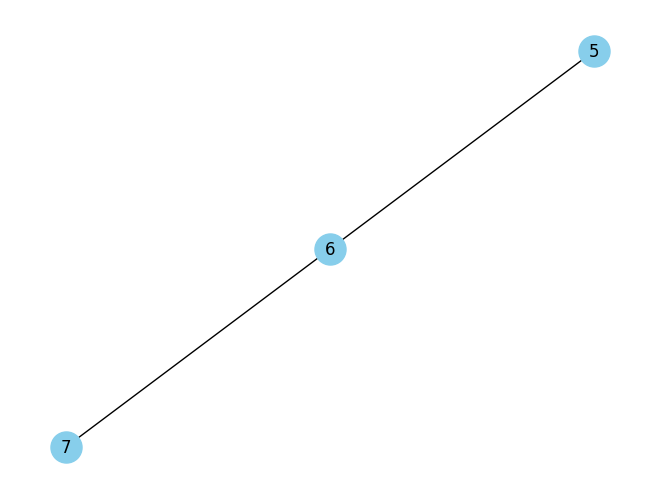

step 3: start a new part dag {}
step 8: Section 2 constructed!
[(5, 7), (6, 5), (5, 7), (5, 4)]


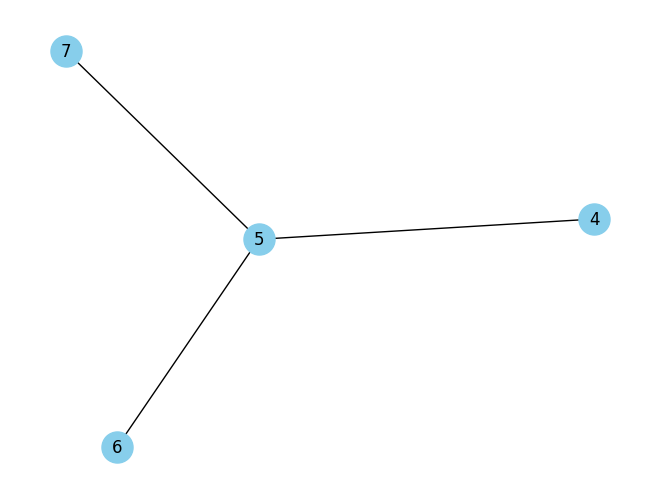

step 8: start a new part dag {}
step 17: Section 3 constructed!
[(4, 7), (6, 4), (4, 7), (5, 4), (4, 7), (6, 4), (4, 7), (4, 3)]


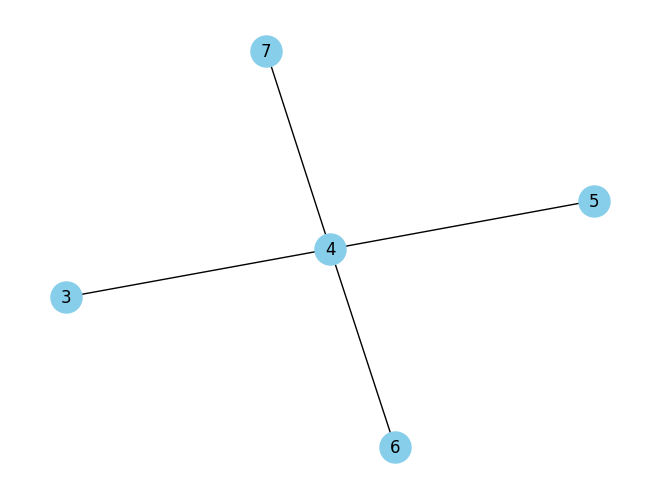

step 17: start a new part dag {}
step 33: Section 4 constructed!
[(3, 7), (6, 3), (3, 7), (5, 3), (3, 7), (6, 3), (3, 7), (4, 3), (3, 7), (6, 3), (3, 7), (5, 3), (3, 7), (6, 3), (3, 7)]


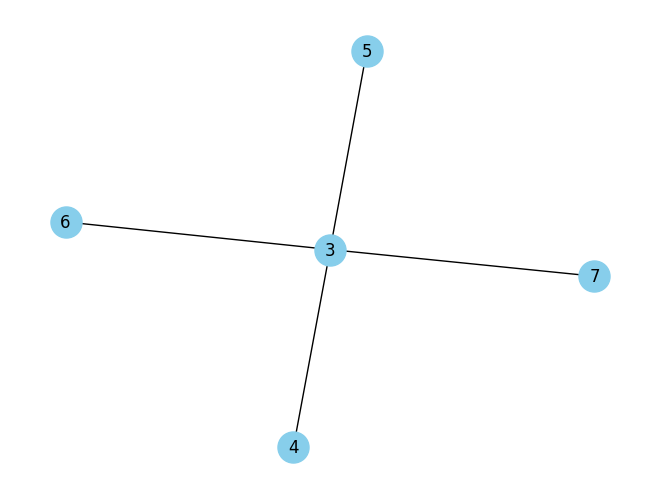

step 33: start a new part dag {}
step 42: Section 5 constructed!
[(3, 2), (2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7)]


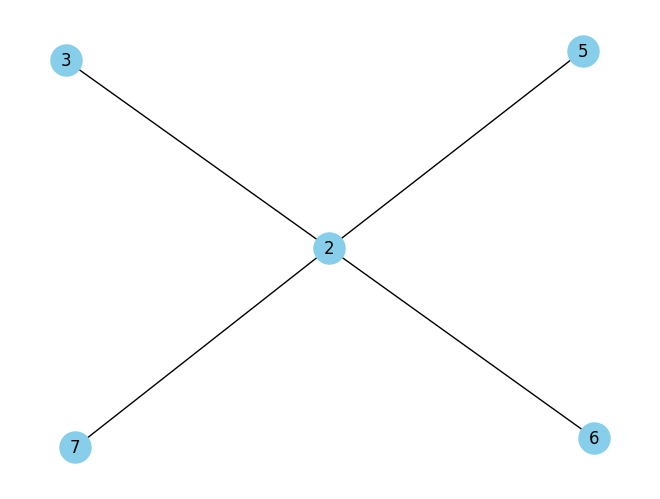

step 42: start a new part dag {}
step 51: Section 6 constructed!
[(4, 2), (2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7)]


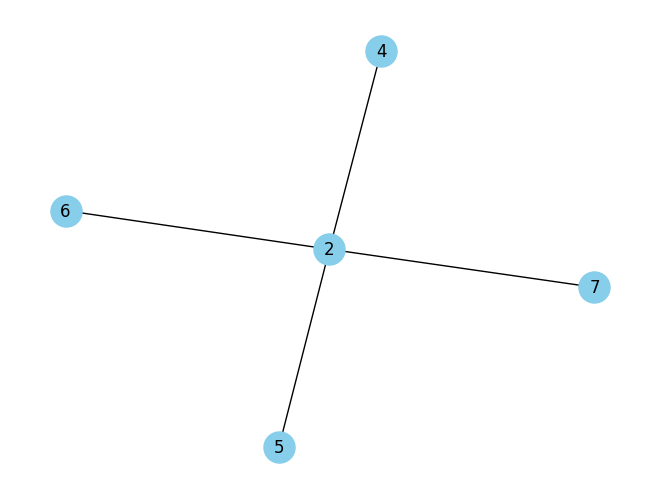

step 51: start a new part dag {}
step 60: Section 7 constructed!
[(3, 2), (2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7)]


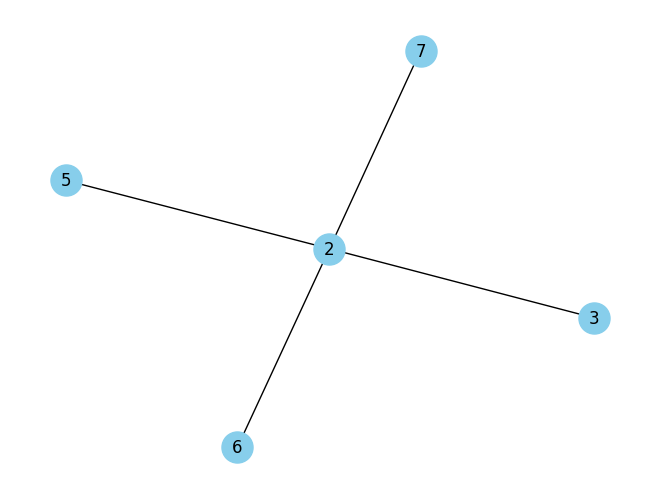

step 60: start a new part dag {}
step 69: Section 8 constructed!
[(4, 2), (2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7)]


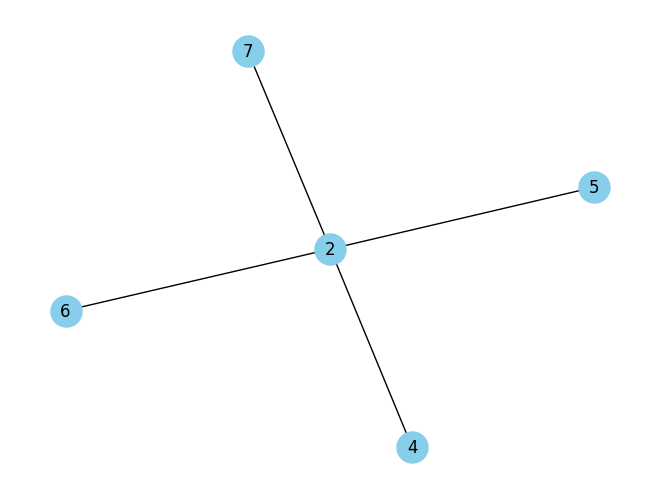

step 69: start a new part dag {}
step 78: Section 9 constructed!
[(2, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


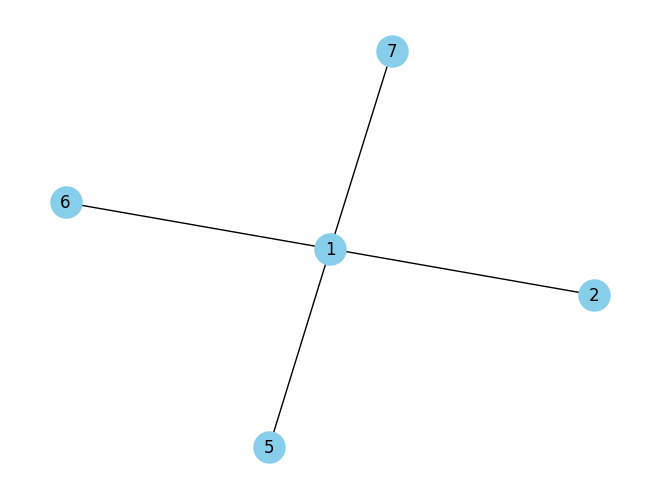

step 78: start a new part dag {}
step 87: Section 10 constructed!
[(4, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


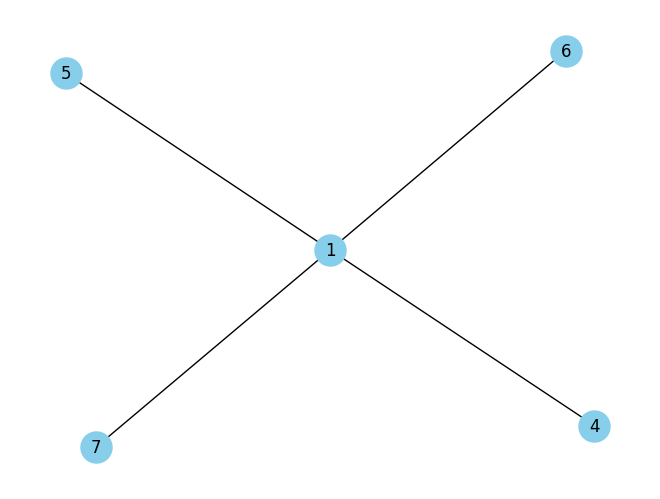

step 87: start a new part dag {}
step 96: Section 11 constructed!
[(3, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


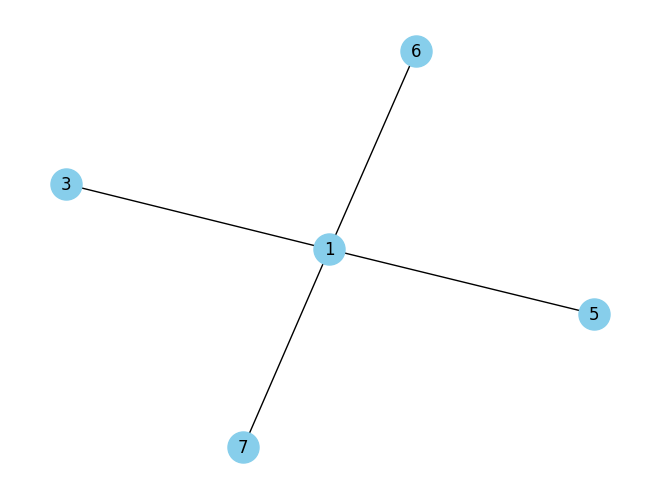

step 96: start a new part dag {}
step 105: Section 12 constructed!
[(4, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


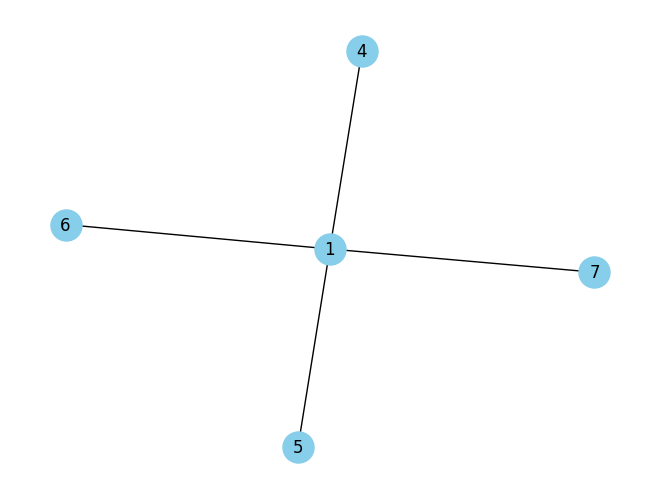

step 105: start a new part dag {}
step 114: Section 13 constructed!
[(2, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


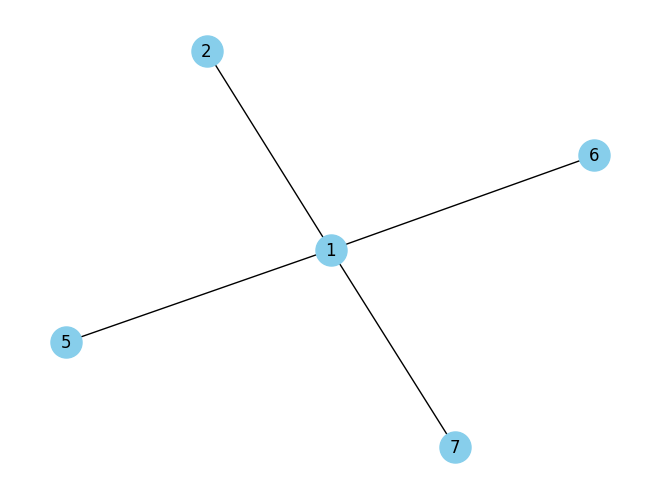

step 114: start a new part dag {}
step 123: Section 14 constructed!
[(4, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


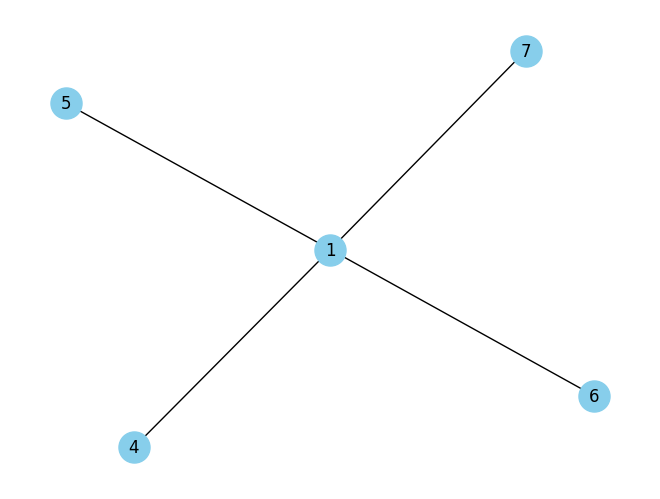

step 123: start a new part dag {}
step 132: Section 15 constructed!
[(3, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


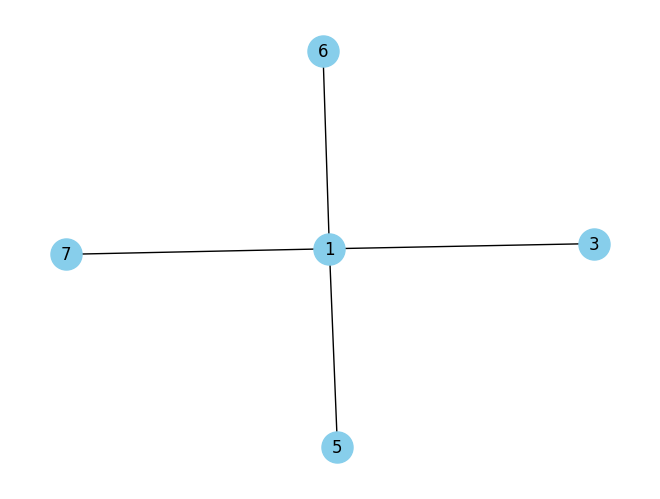

step 132: start a new part dag {}
step 141: Section 16 constructed!
[(4, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


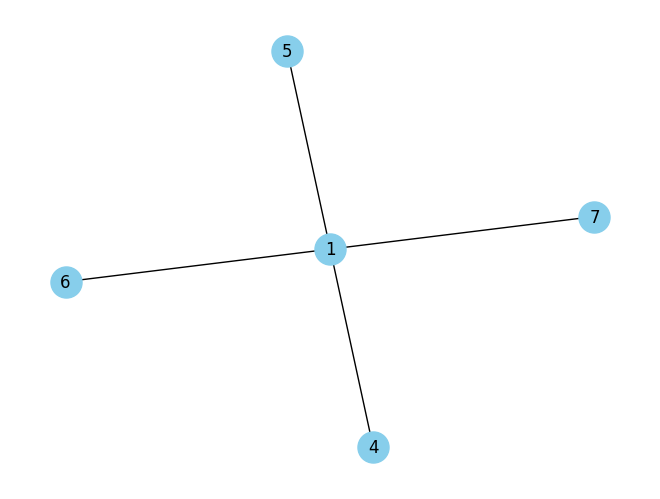

step 141: start a new part dag {}
step 150: Section 17 constructed!
[(1, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


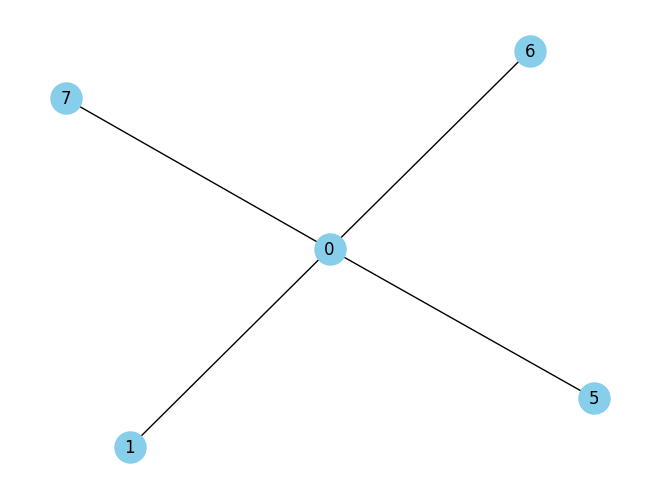

step 150: start a new part dag {}
step 159: Section 18 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


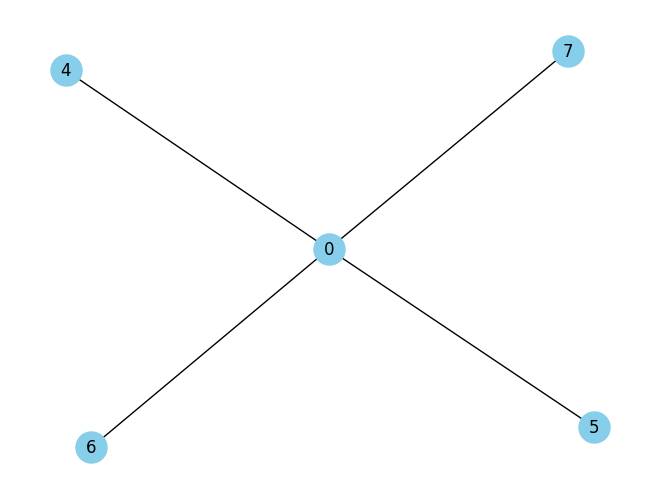

step 159: start a new part dag {}
step 168: Section 19 constructed!
[(3, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


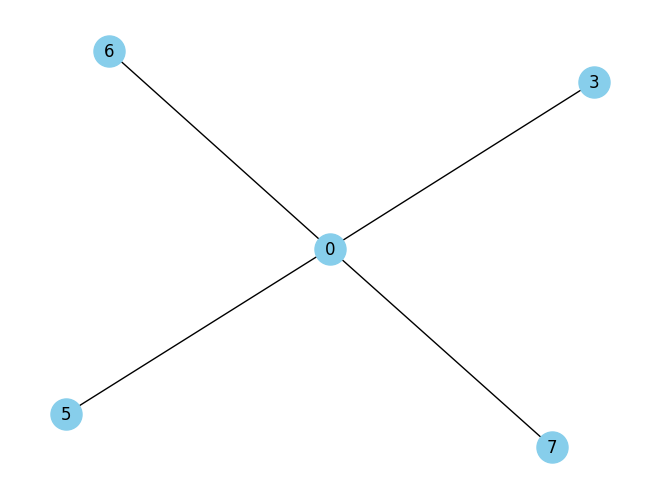

step 168: start a new part dag {}
step 177: Section 20 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


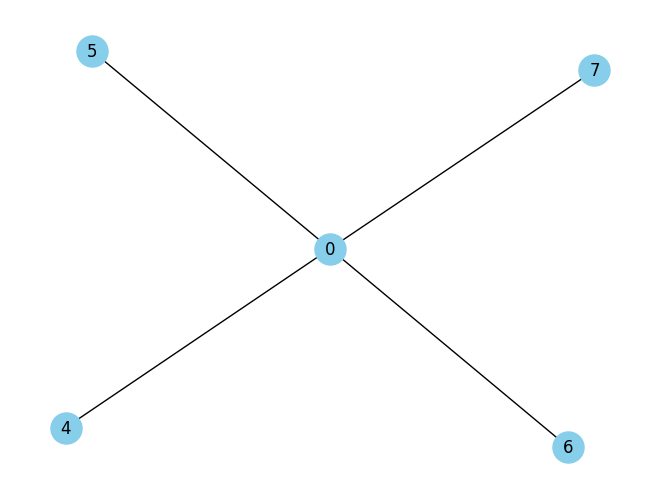

step 177: start a new part dag {}
step 186: Section 21 constructed!
[(2, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


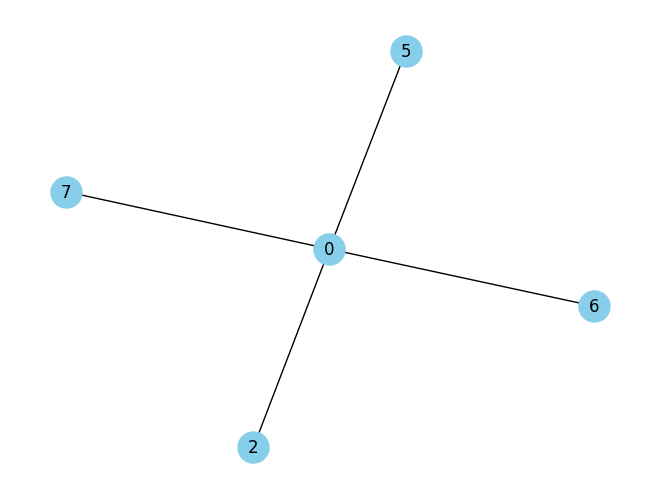

step 186: start a new part dag {}
step 195: Section 22 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


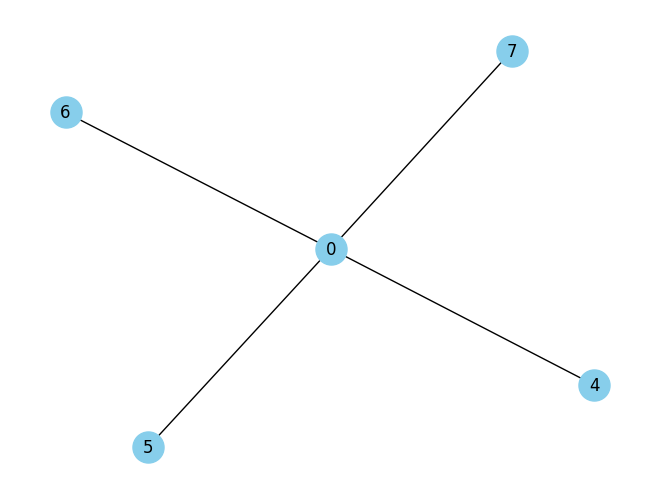

step 195: start a new part dag {}
step 204: Section 23 constructed!
[(3, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


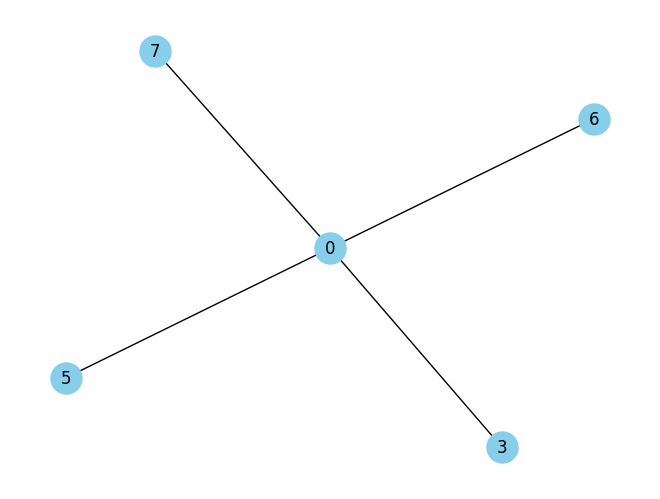

step 204: start a new part dag {}
step 213: Section 24 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


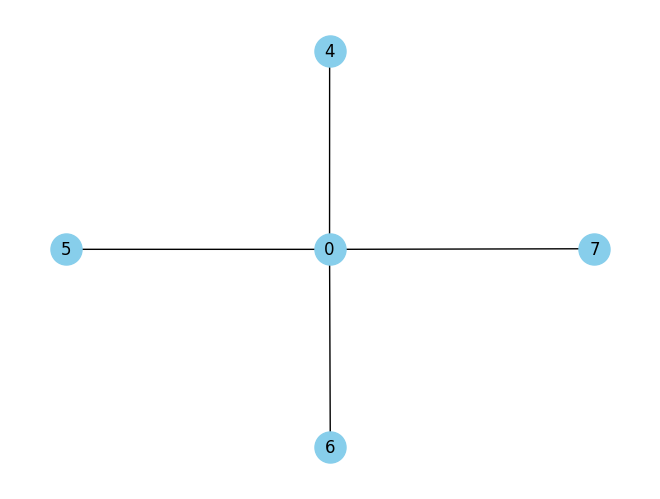

step 213: start a new part dag {}
step 222: Section 25 constructed!
[(1, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


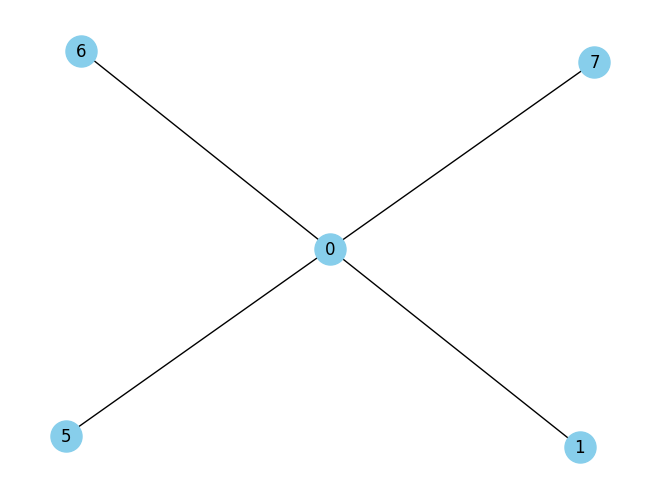

step 222: start a new part dag {}
step 231: Section 26 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


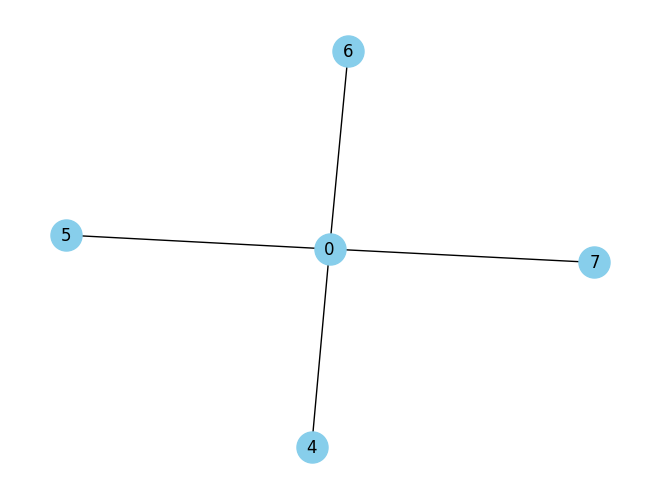

step 231: start a new part dag {}
step 240: Section 27 constructed!
[(3, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


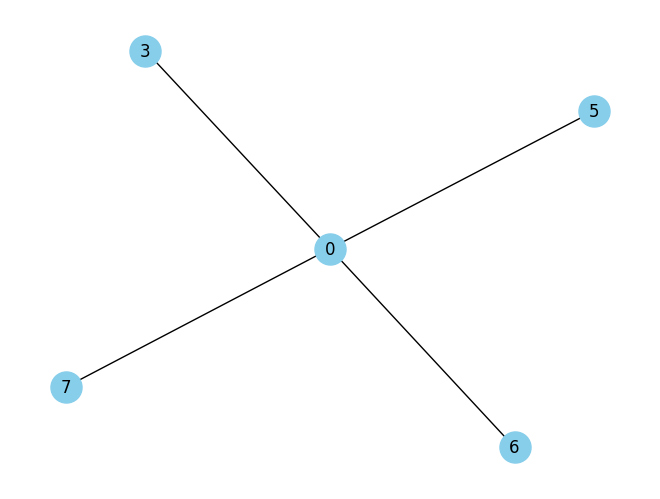

step 240: start a new part dag {}
step 249: Section 28 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


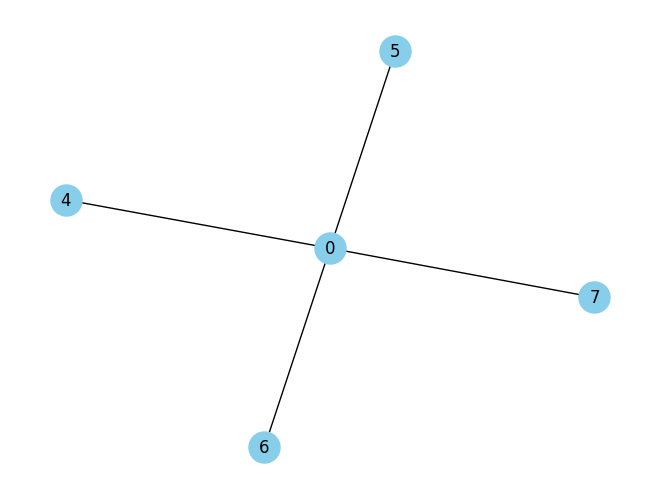

step 249: start a new part dag {}
step 258: Section 29 constructed!
[(2, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


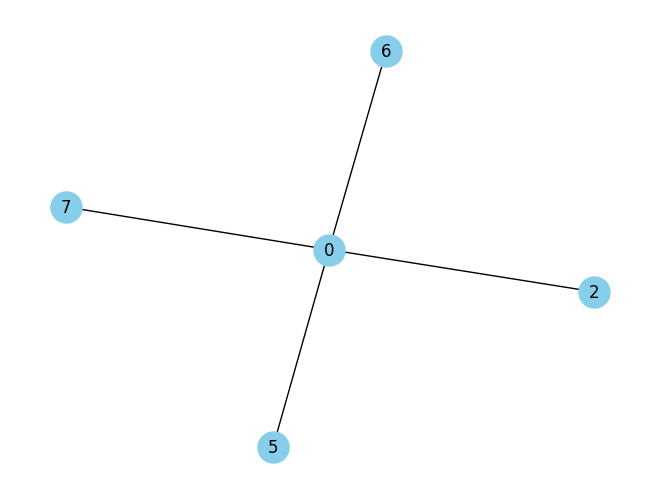

step 258: start a new part dag {}
step 267: Section 30 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


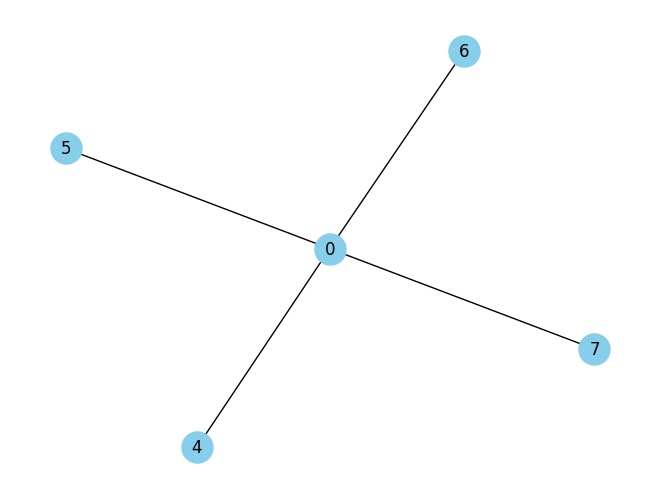

step 267: start a new part dag {}
step 276: Section 31 constructed!
[(3, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


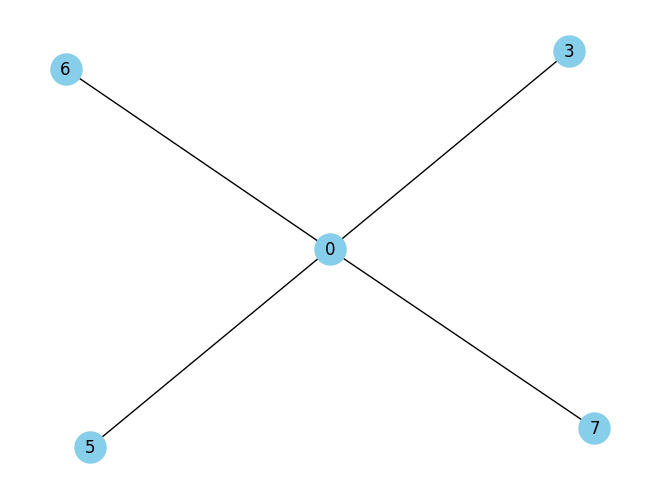

step 276: start a new part dag {}
step 284: Section 32 constructed!
[(4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


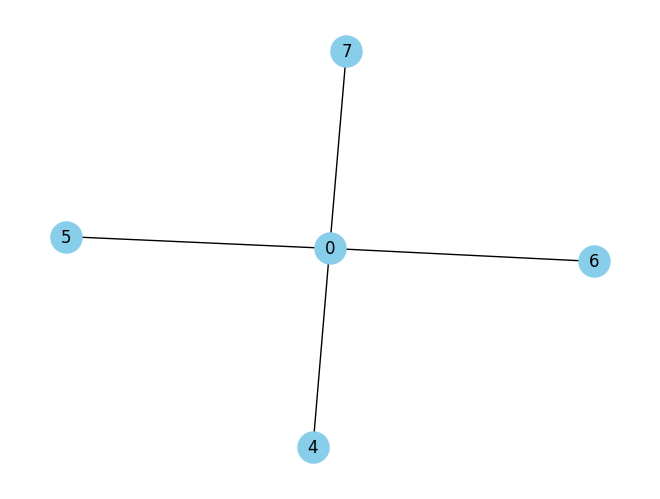

253 cx gates have been processed.
The partition is complete and we have 32 sections!


In [897]:
X = partition(dag, AG, method='greedy')

In [898]:
def has_descendnent(node, dag):
    S = [s for s in _successors(node, dag) if isinstance(s,DAGOpNode)]
    if S:
        return True
    return False

def realign(dag1, dag2):
    
    qc2 =  dag_to_circuit(dag2)
    graph2 = graph_of_circuit(qc2)  
    nodes_in_reverse_topological_order = list(reversed(list(dag1.topological_op_nodes())))

    for node in nodes_in_reverse_topological_order:
        if not isinstance(node, DAGOpNode) or has_descendnent(node, dag1): continue
        if (node.qargs[0]._index, node.qargs[1]._index) in graph2.edges():
            dag1.remove_op_node(node)
            dag2.apply_operation_front(node.op, node.qargs, node.cargs)
    return dag1, dag2

step 0 of 32. ({'cx': 2}, {'cx': 1})
step 1 of 32. ({'cx': 4}, {'cx': 4})
step 2 of 32. ({'cx': 8}, {'cx': 8})
step 3 of 32. ({'cx': 15}, {'cx': 16})
step 4 of 32. ({'cx': 8}, {'cx': 1})
step 5 of 32. ({'cx': 8}, {'cx': 8})
step 6 of 32. ({'cx': 8}, {'cx': 8})
step 7 of 32. ({'cx': 8}, {'cx': 15})
step 8 of 32. ({'cx': 8}, {'cx': 1})
step 9 of 32. ({'cx': 8}, {'cx': 8})
step 10 of 32. ({'cx': 8}, {'cx': 8})
step 11 of 32. ({'cx': 8}, {'cx': 8})
step 12 of 32. ({'cx': 8}, {'cx': 8})
step 13 of 32. ({'cx': 8}, {'cx': 8})
step 14 of 32. ({'cx': 8}, {'cx': 8})
step 15 of 32. ({'cx': 8}, {'cx': 15})
step 16 of 32. ({'cx': 8}, {'cx': 1})
step 17 of 32. ({'cx': 8}, {'cx': 8})
step 18 of 32. ({'cx': 8}, {'cx': 8})
step 19 of 32. ({'cx': 8}, {'cx': 8})
step 20 of 32. ({'cx': 8}, {'cx': 8})
step 21 of 32. ({'cx': 8}, {'cx': 8})
step 22 of 32. ({'cx': 8}, {'cx': 8})
step 23 of 32. ({'cx': 8}, {'cx': 8})
step 24 of 32. ({'cx': 8}, {'cx': 8})
step 25 of 32. ({'cx': 8}, {'cx': 8})
step 26 of 32. ({'

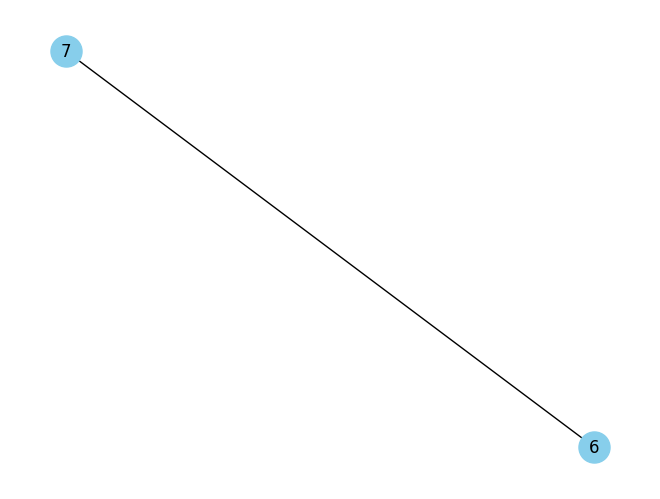

Modified Section 1 has CX gates
[(6, 5), (5, 7), (6, 5), (5, 7)]


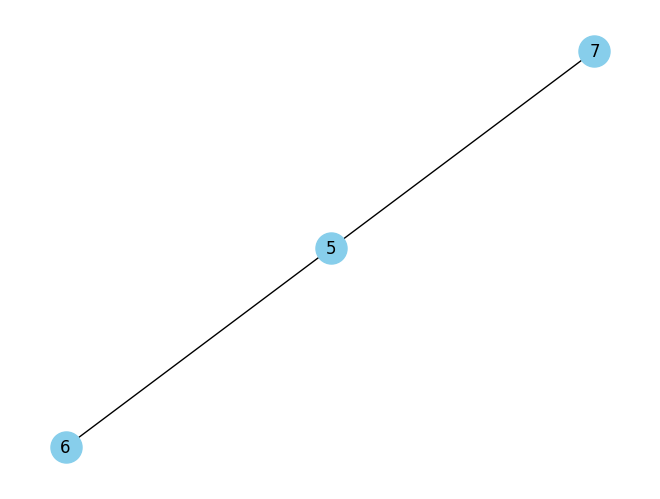

Modified Section 2 has CX gates
[(5, 4), (4, 7), (6, 4), (4, 7), (5, 4), (4, 7), (6, 4), (4, 7)]


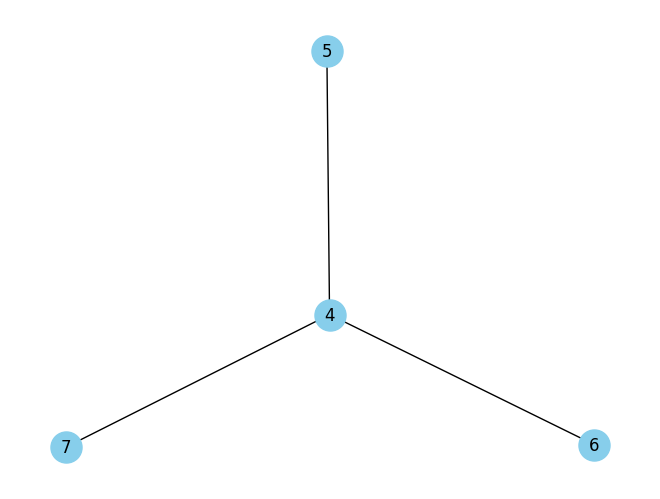

Modified Section 3 has CX gates
[(4, 3), (3, 7), (6, 3), (3, 7), (5, 3), (3, 7), (6, 3), (3, 7), (4, 3), (3, 7), (6, 3), (3, 7), (5, 3), (3, 7), (6, 3), (3, 7)]


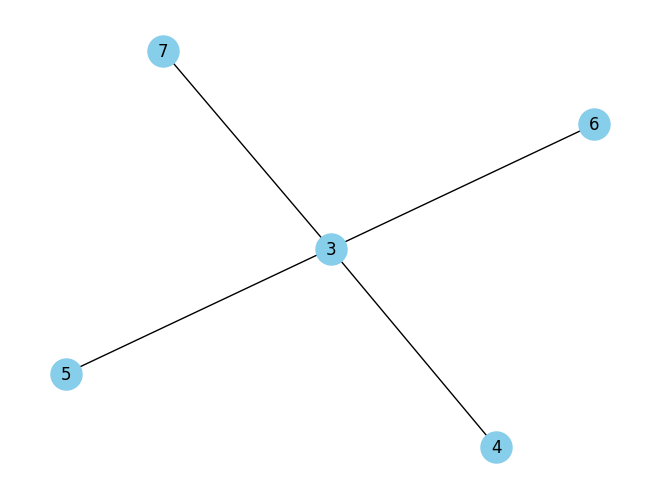

Modified Section 4 has CX gates
[(3, 2)]


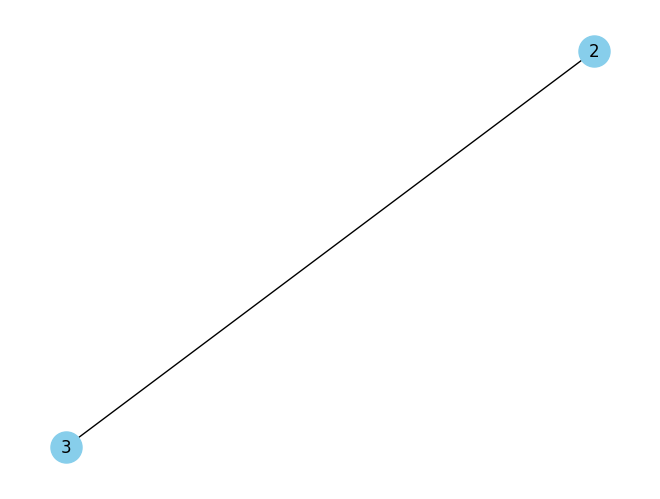

Modified Section 5 has CX gates
[(2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7), (4, 2)]


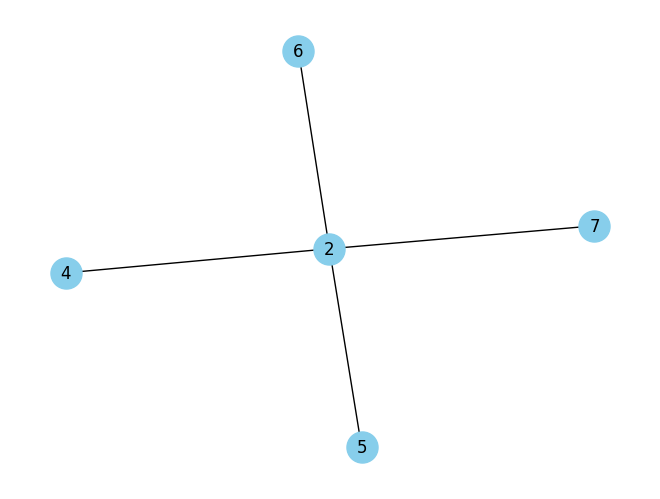

Modified Section 6 has CX gates
[(2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7), (3, 2)]


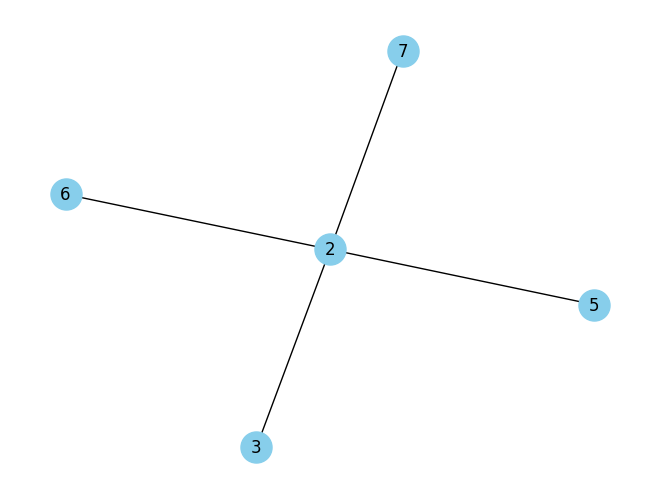

Modified Section 7 has CX gates
[(2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7), (4, 2), (2, 7), (6, 2), (2, 7), (5, 2), (2, 7), (6, 2), (2, 7)]


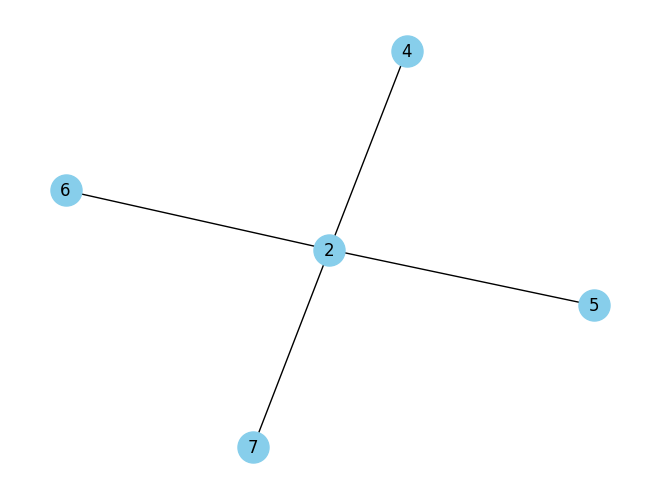

Modified Section 8 has CX gates
[(2, 1)]


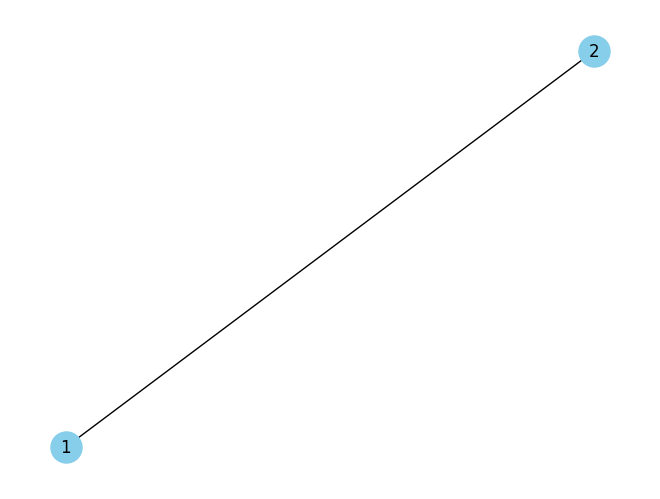

Modified Section 9 has CX gates
[(1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7), (4, 1)]


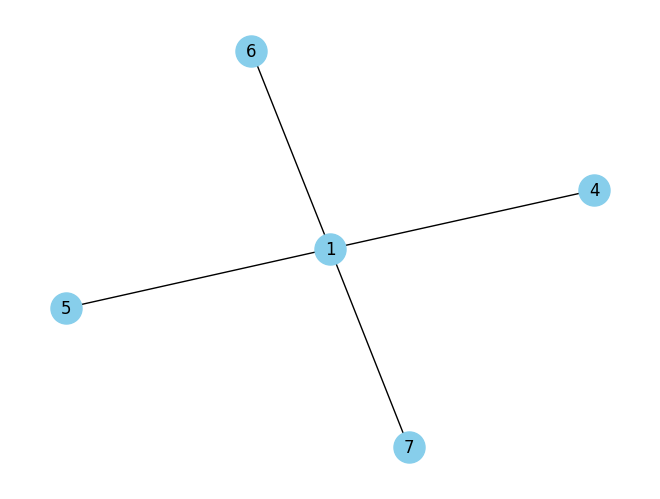

Modified Section 10 has CX gates
[(1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7), (3, 1)]


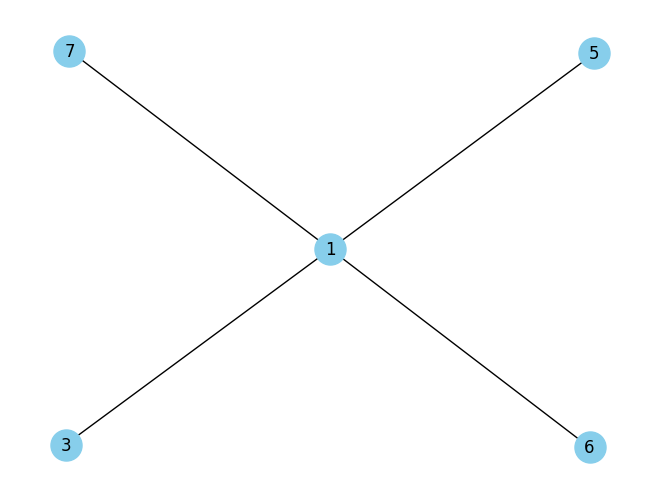

Modified Section 11 has CX gates
[(1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7), (4, 1)]


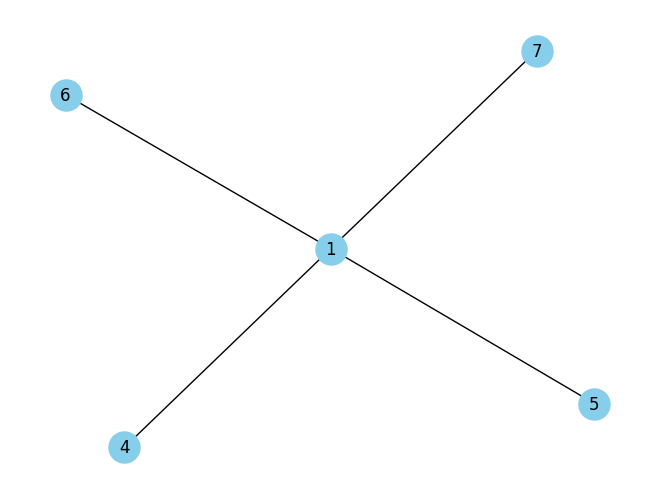

Modified Section 12 has CX gates
[(1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7), (2, 1)]


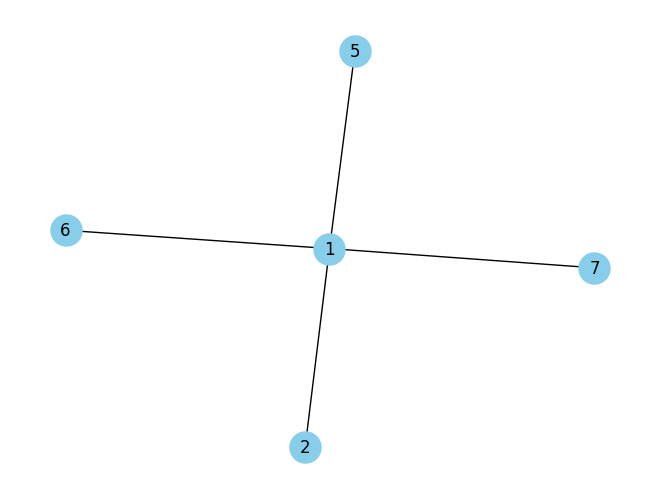

Modified Section 13 has CX gates
[(1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7), (4, 1)]


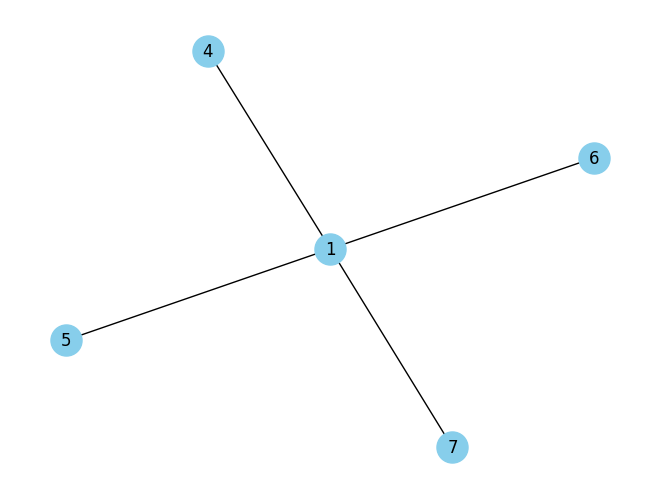

Modified Section 14 has CX gates
[(1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7), (3, 1)]


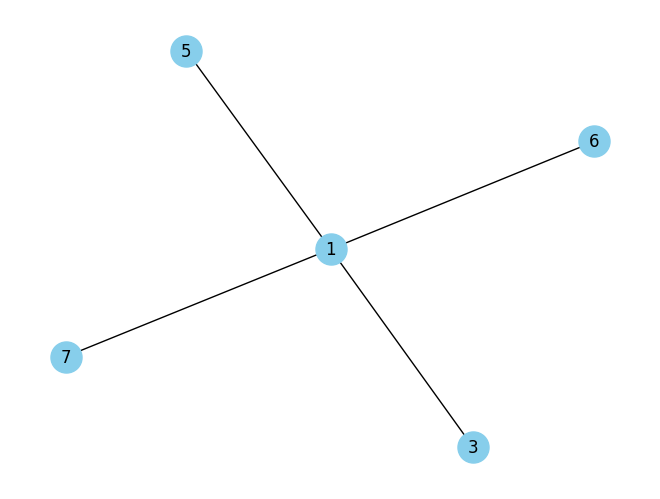

Modified Section 15 has CX gates
[(1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7), (4, 1), (1, 7), (6, 1), (1, 7), (5, 1), (1, 7), (6, 1), (1, 7)]


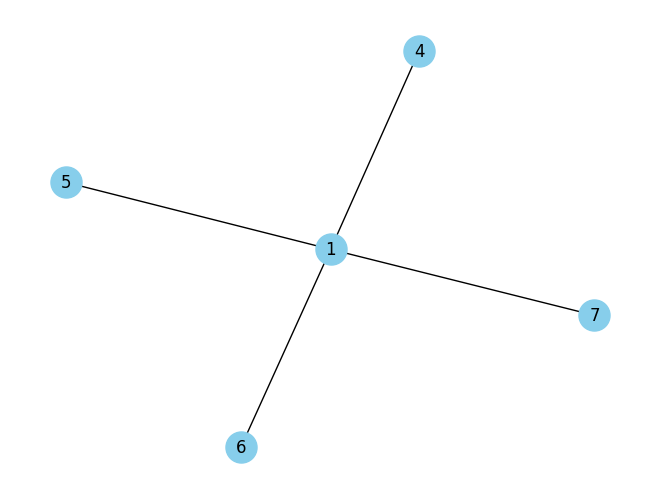

Modified Section 16 has CX gates
[(1, 0)]


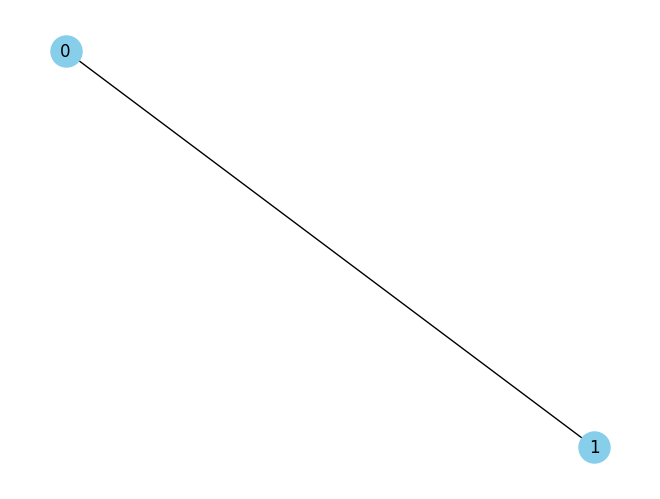

Modified Section 17 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0)]


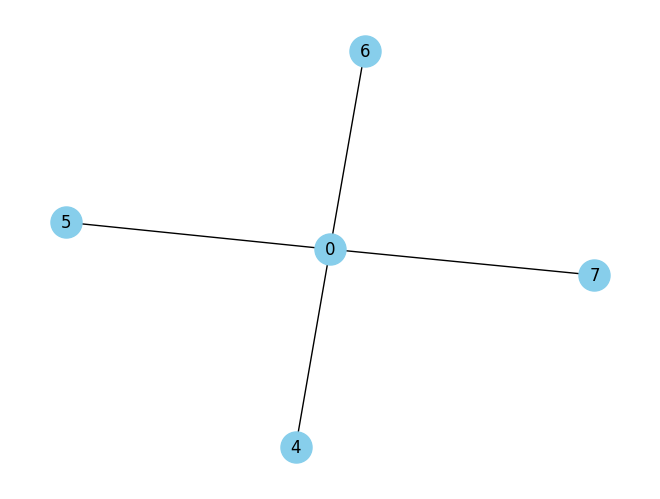

Modified Section 18 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (3, 0)]


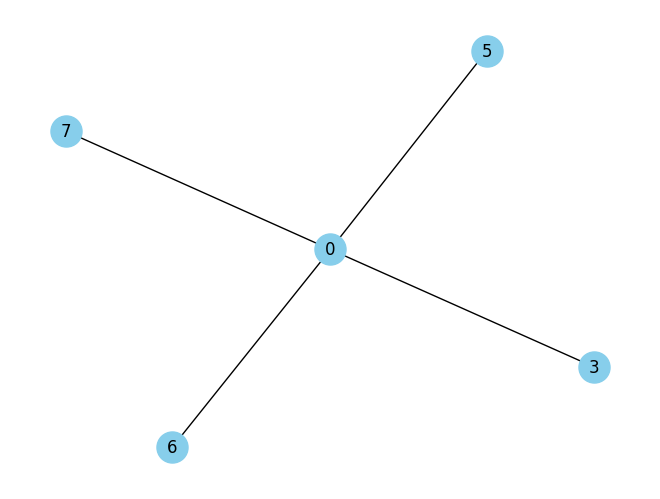

Modified Section 19 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0)]


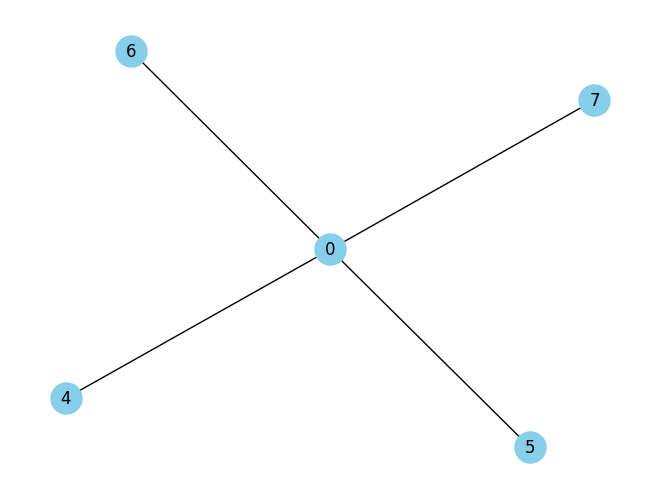

Modified Section 20 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (2, 0)]


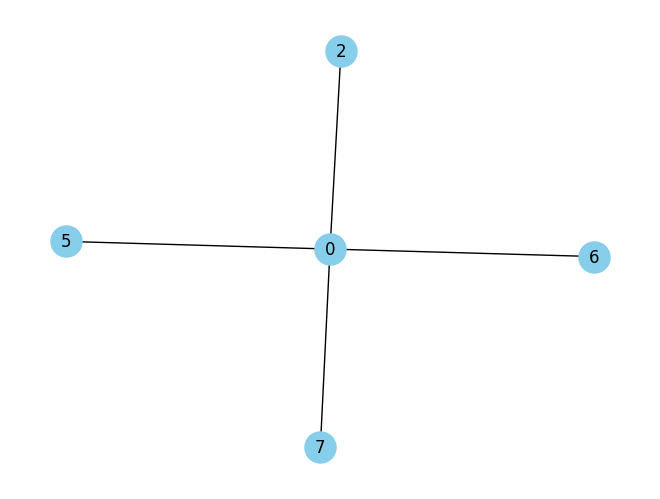

Modified Section 21 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0)]


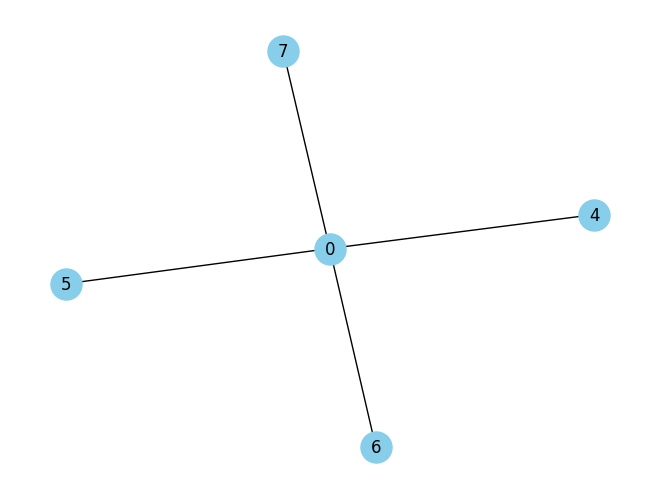

Modified Section 22 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (3, 0)]


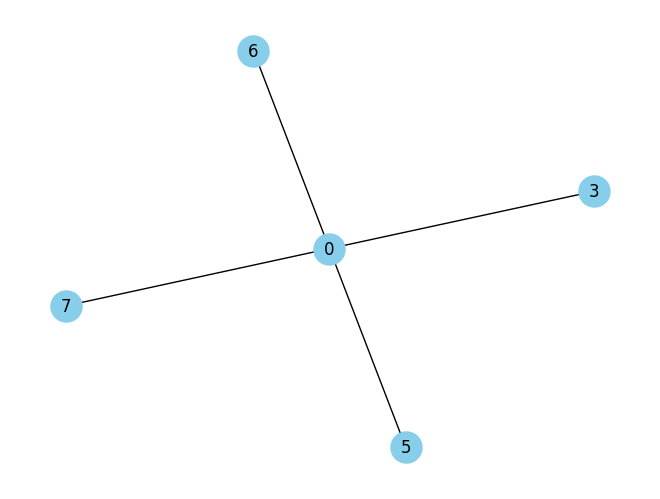

Modified Section 23 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0)]


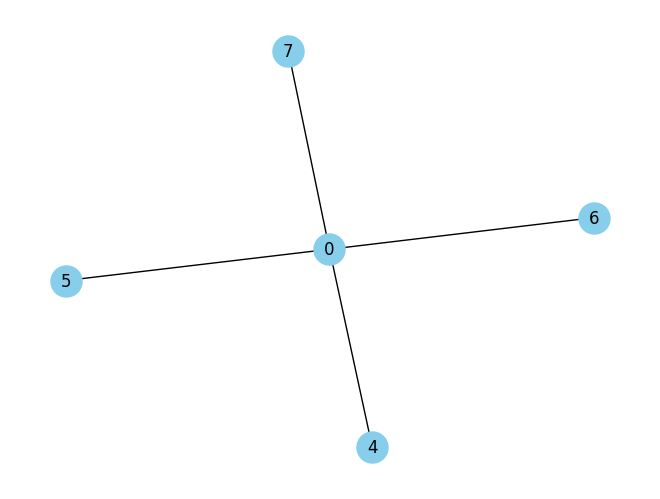

Modified Section 24 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (1, 0)]


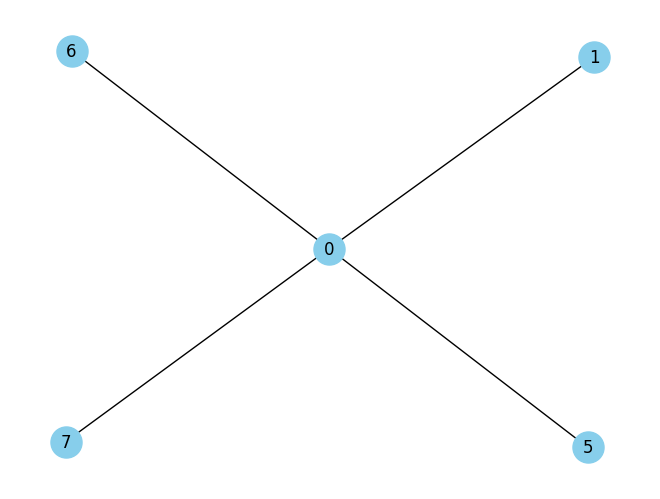

Modified Section 25 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0)]


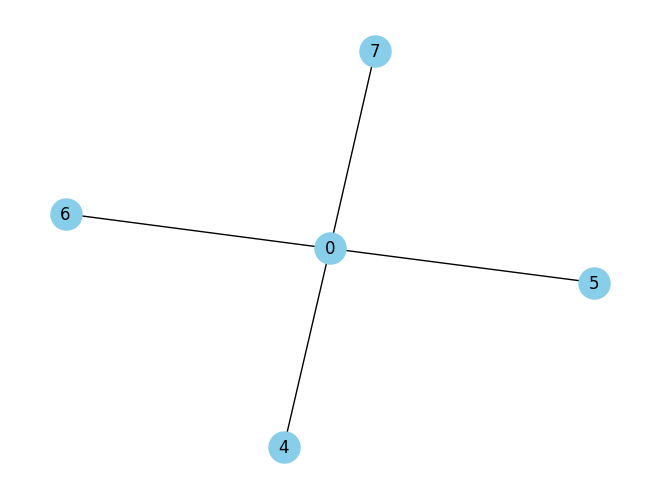

Modified Section 26 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (3, 0)]


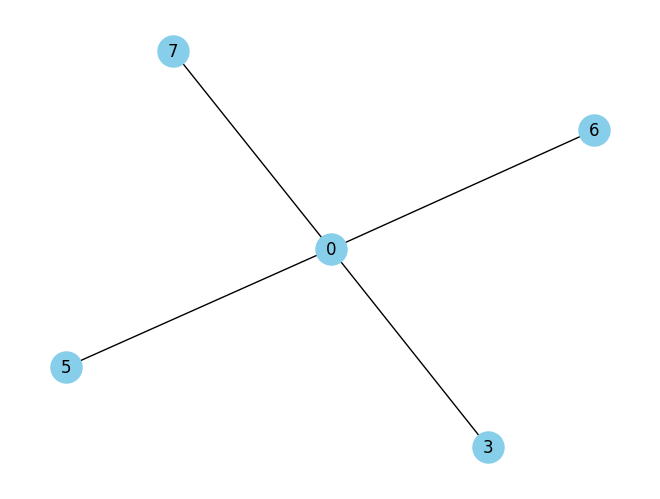

Modified Section 27 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0)]


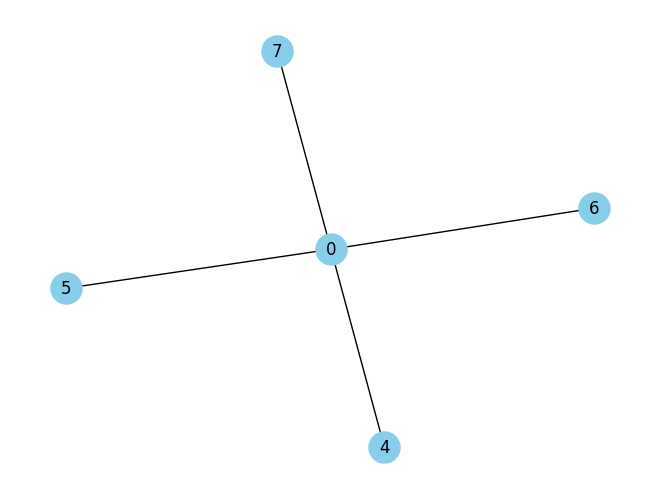

Modified Section 28 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (2, 0)]


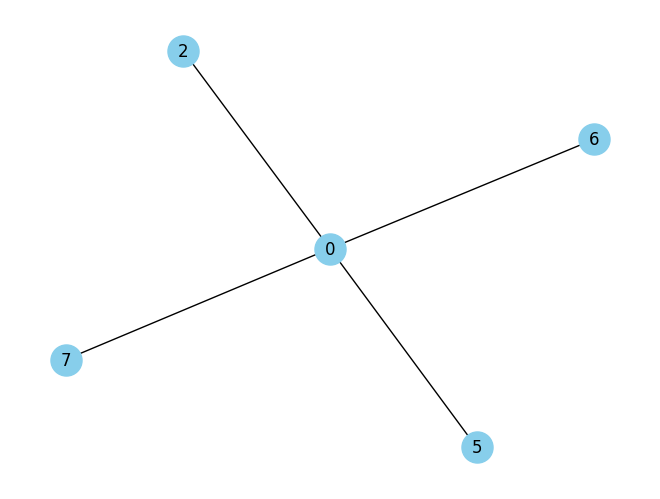

Modified Section 29 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0)]


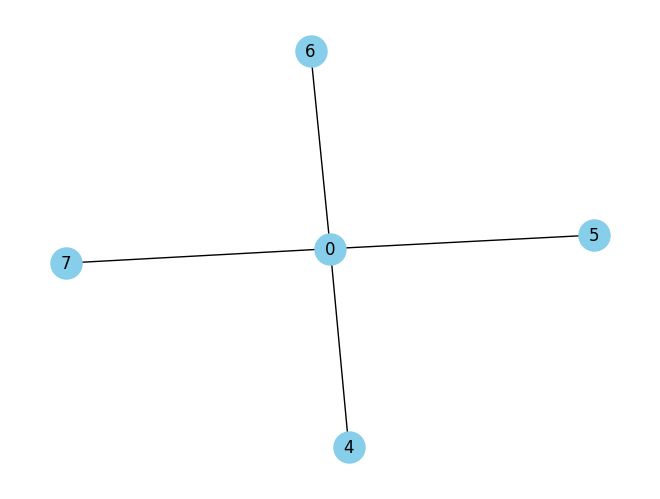

Modified Section 30 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (3, 0)]


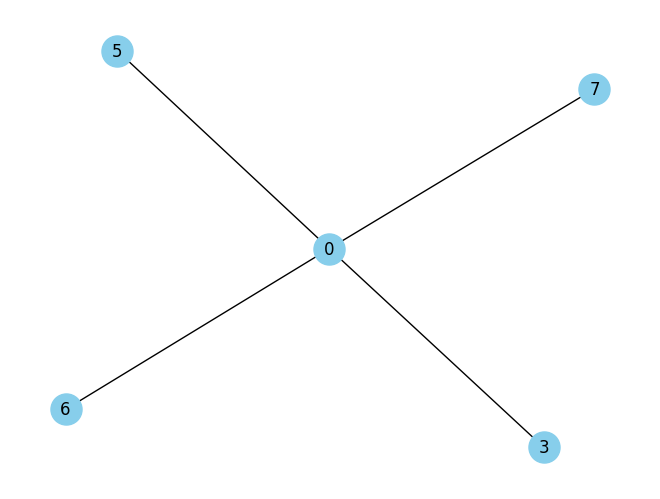

Modified Section 31 has CX gates
[(0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7), (4, 0), (0, 7), (6, 0), (0, 7), (5, 0), (0, 7), (6, 0), (0, 7)]


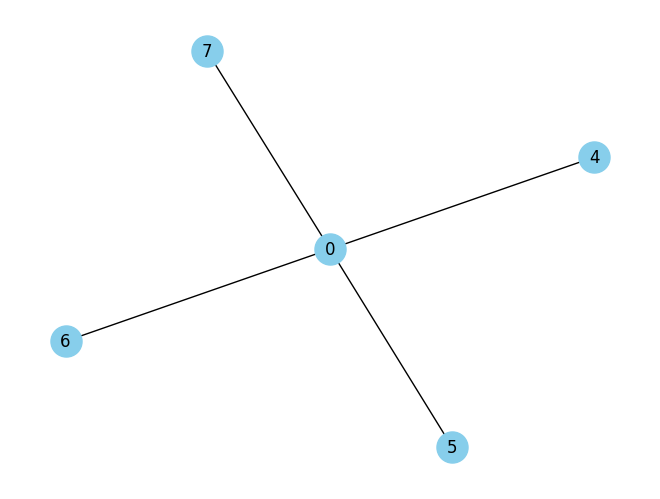

In [900]:
W = copy.deepcopy(X)


for i in range(len(W)-1):
    W[i], W[i+1] = realign(W[i], W[i+1])

for i in range(len(X)):
    print(f'step {i} of {len(X)}. {X[i].count_ops(),W[i].count_ops()}')
    
print(sum([X[i].count_ops()['cx'] for i in range(len(X))]))
print(sum([W[i].count_ops()['cx'] for i in range(len(W))]))

for i in range(len(W)):
    print(f'Modified Section {i} has CX gates')
    print([(node.qargs[0]._index, node.qargs[1]._index) for node\
           in W[i].topological_op_nodes() if isinstance(node, DAGOpNode)])
    draw_nx_graph(W[i])